<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/06_pytorch_transfer_learning_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. PyTorch Transfer Learning Exercises

Welcome to the 06. PyTorch Transfer Learning exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.

## Resources and solutions

* These exercises/solutions are based on [section 06. PyTorch Transfer Learning](https://www.learnpytorch.io/06_pytorch_transfer_learning/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.

**Solutions:** 

Try to complete the code below *before* looking at these.

* See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/ueLolShyFqs).
* See an example [solutions notebook for these exercises on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/06_pytorch_transfer_learning_exercise_solutions.ipynb).

## 1. Make predictions on the entire test dataset and plot a confusion matrix for the results of our model compared to the truth labels. 
* **Note:** You will need to get the dataset and the trained model/retrain the model from notebook 06 to perform predictions.
* Check out [03. PyTorch Computer Vision section 10](https://www.learnpytorch.io/03_pytorch_computer_vision/#10-making-a-confusion-matrix-for-further-prediction-evaluation) for ideas.

In [1]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms, datasets

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    %pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory
try:
    from going_modular.going_modular import data_setup, engine
except ImportError:
    # This repo already has going_modular/ two directories up (../../going_modular),
    # so point Python at it instead of git-cloning the whole (1GB+) repo again.
    import sys
    from pathlib import Path
    repo_root = Path.cwd()
    while not (repo_root / "going_modular").is_dir() and repo_root != repo_root.parent:
        repo_root = repo_root.parent
    if (repo_root / "going_modular").is_dir():
        print(f"[INFO] Found going_modular at {repo_root / 'going_modular'}, adding it to sys.path.")
        sys.path.insert(0, str(repo_root / "going_modular"))
        from going_modular import data_setup, engine
    else:
        print("[INFO] Couldn't find going_modular scripts locally... downloading them from GitHub.")
        !git clone https://github.com/mrdbourke/pytorch-deep-learning
        !mv pytorch-deep-learning/going_modular .
        !rm -rf pytorch-deep-learning
        from going_modular.going_modular import data_setup, engine

[INFO] Found going_modular at D:\computer vision\baith02_cv_DoanThiThuLinh\pytorch-deep-learning\going_modular, adding it to sys.path.


In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### Get data 

In [3]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

data\pizza_steak_sushi directory exists.


### Prepare data

In [4]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [5]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1fff4e04c20>,
 ['pizza', 'steak', 'sushi'])

### Get and prepare a pretrained model

In [6]:
# Setup the model with pretrained weights and send it to the target device 
model_0 = torchvision.models.efficientnet_b0(pretrained=True).to(device)
#model_0 # uncomment to output (it's very long)

In [7]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [8]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True), 
    torch.nn.Linear(in_features=1280, 
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

### Train model

In [9]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

In [10]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer 
start_time = timer()

# Setup training and save the results
model_0_results = engine.train(model=model_0,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:32<02:10, 32.70s/it]

Epoch: 1 | train_loss: 1.0963 | train_acc: 0.3984 | test_loss: 0.8989 | test_acc: 0.5597


 40%|████      | 2/5 [01:03<01:35, 31.78s/it]

Epoch: 2 | train_loss: 0.9230 | train_acc: 0.6680 | test_loss: 0.8171 | test_acc: 0.7131


...

 80%|████████  | 4/5 [02:10<00:32, 32.98s/it]

Epoch: 4 | train_loss: 0.7408 | train_acc: 0.7109 | test_loss: 0.6582 | test_acc: 0.8759


100%|██████████| 5/5 [02:43<00:00, 32.91s/it]

100%|██████████| 5/5 [02:43<00:00, 32.65s/it]

Epoch: 5 | train_loss: 0.6206 | train_acc: 0.7773 | test_loss: 0.6028 | test_acc: 0.9072
[INFO] Total training time: 163.234 seconds


### Make predictions on the entire test dataset with the model

In [11]:
# Make predictions across the entire test dataset with model_0

y_preds = []
y_true = []
model_0.eval()
with torch.inference_mode():
  for X, y in test_dataloader:
    X, y = X.to(device), y.to(device)
    y_logits = model_0(X)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())
    y_true.append(y.cpu())

y_preds = torch.cat(y_preds)
y_true = torch.cat(y_true)
len(y_preds), len(y_true)

(75, 75)

### Make a confusion matrix with the test preds and the truth labels

Need the following libraries to make a confusion matrix:
* torchmetrics - https://torchmetrics.readthedocs.io/en/stable/
* mlxtend - http://rasbt.github.io/mlxtend/

In [12]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.25.0


In [13]:
# Import mlxtend upgraded version
import mlxtend 
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.25.0


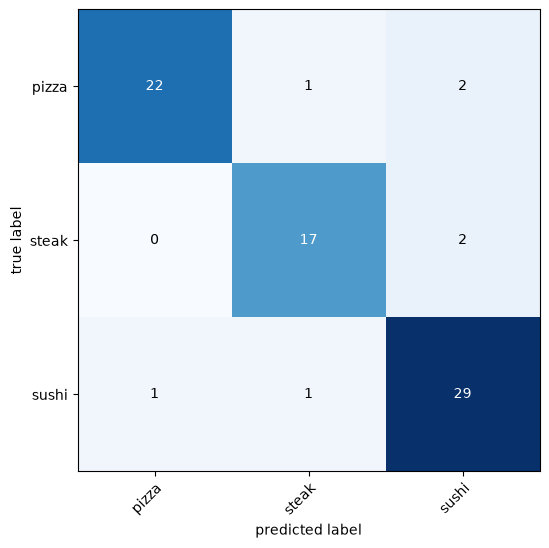

In [14]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix instance
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_preds, target=y_true)

# Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(8, 6)
)

## 2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

In [15]:
# Get "most wrong" predictions: predict across the test dataset, keep the image path,
# true label, predicted label and predicted probability for every sample.
import pandas as pd

test_data = datasets.ImageFolder(test_dir, transform=simple_transform)
test_paths = [Path(p) for p, _ in test_data.samples]

y_pred_probs = []
y_preds_full = []
model_0.eval()
with torch.inference_mode():
  for X, y in test_dataloader:
    X = X.to(device)
    y_logits = model_0(X)
    probs = torch.softmax(y_logits, dim=1)
    y_pred_probs.append(probs.max(dim=1).values.cpu())
    y_preds_full.append(probs.argmax(dim=1).cpu())

y_pred_probs = torch.cat(y_pred_probs)
y_preds_full = torch.cat(y_preds_full)

pred_df = pd.DataFrame({
    "image_path": test_paths,
    "label": [class_names[i] for i in y_true],
    "pred": [class_names[i] for i in y_preds_full],
    "pred_prob": y_pred_probs.numpy(),
})
pred_df["correct"] = pred_df["label"] == pred_df["pred"]

# Sort: wrong predictions first, then by descending confidence ("most wrong" on top)
most_wrong = pred_df[~pred_df["correct"]].sort_values("pred_prob", ascending=False).head(5)
most_wrong

,image_path,label,pred,pred_prob,correct
70,data\pizza_steak_sushi\test\sushi\684266.jpg,sushi,steak,0.541481,False
34,data\pizza_steak_sushi\test\steak\27415.jpg,steak,sushi,0.494143,False
27,data\pizza_steak_sushi\test\steak\1285886.jpg,steak,sushi,0.468533,False
57,data\pizza_steak_sushi\test\sushi\2394442.jpg,sushi,pizza,0.462191,False
12,data\pizza_steak_sushi\test\pizza\2508636.jpg,pizza,sushi,0.415967,False


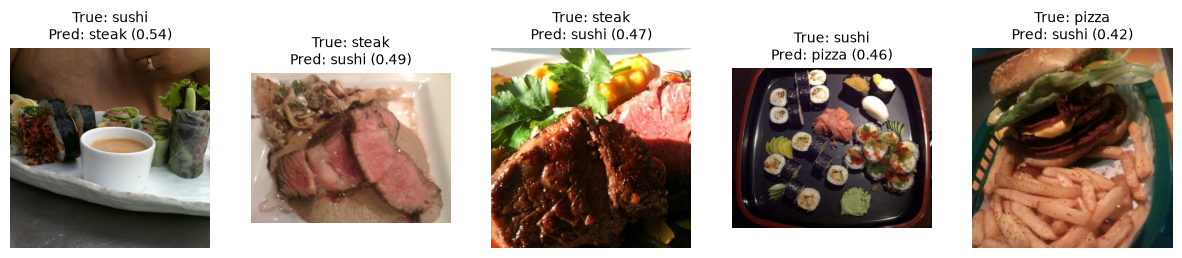

In [16]:
# Plot the top 5 "most wrong" images
plt.figure(figsize=(15, 6))
for i, (_, row) in enumerate(most_wrong.iterrows()):
  img = torchvision.io.read_image(str(row["image_path"]))
  plt.subplot(1, 5, i + 1)
  plt.imshow(img.permute(1, 2, 0))
  plt.title(f"True: {row['label']}\nPred: {row['pred']} ({row['pred_prob']:.2f})", fontsize=10)
  plt.axis(False)

**Nhận xét:** những ảnh mô hình dự đoán sai với độ tự tin cao thường là các ảnh có đặc điểm thị giác dễ gây nhầm lẫn
giữa các lớp (ví dụ món ăn được trình bày/xếp đĩa theo cách không điển hình, góc chụp lạ, nhiều nguyên liệu trộn lẫn,
hoặc ảnh có màu sắc/ánh sáng gần giống lớp khác). Đây thường là lỗi của dữ liệu (nhãn khó phân biệt ngay cả với người)
nhiều hơn là lỗi hoàn toàn của mô hình.

## 3. Predict on your own image of pizza/steak/sushi - how does the model go? What happens if you predict on an image that isn't pizza/steak/sushi?
* Here you can get an image from a website like http://www.unsplash.com to try it out or you can upload your own.

('pizza', 0.5726245641708374)

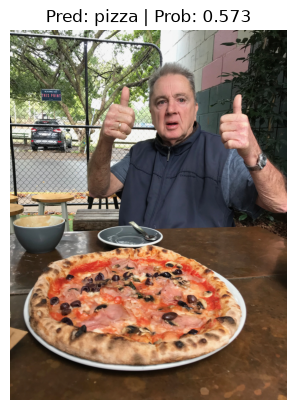

In [17]:
# Predict on a custom pizza/steak/sushi image (the pizza image bundled with the course repo)
from PIL import Image

custom_food_image_path = Path("../../images/04-pizza-dad.jpeg")

def predict_and_plot(model, image_path, transform, class_names, device):
  img = Image.open(image_path)
  transformed_img = transform(img).unsqueeze(dim=0).to(device)

  model.eval()
  with torch.inference_mode():
    pred_logits = model(transformed_img)
  pred_prob = torch.softmax(pred_logits, dim=1)
  pred_label = class_names[pred_prob.argmax(dim=1).item()]

  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {pred_label} | Prob: {pred_prob.max():.3f}")
  plt.axis(False)
  return pred_label, pred_prob.max().item()

predict_and_plot(model_0, custom_food_image_path, simple_transform, class_names, device)

('steak', 0.4717751741409302)

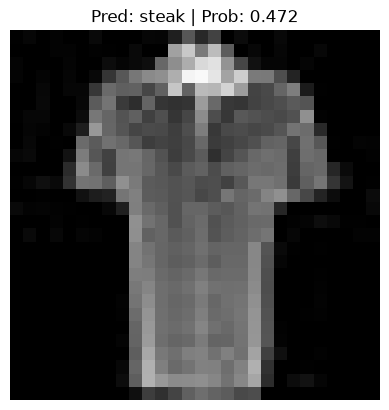

In [18]:
# Predict on an image that ISN'T pizza/steak/sushi (a t-shirt photo bundled with the repo)
custom_non_food_image_path = Path("../../images/03_shirt_image.jpeg")
predict_and_plot(model_0, custom_non_food_image_path, simple_transform, class_names, device)

**Nhận xét:** vì lớp cuối của mô hình chỉ có đúng 3 output (pizza/steak/sushi) và dùng softmax, mô hình bị *buộc*
phải chọn một trong 3 lớp đó dù ảnh chẳng liên quan gì đến đồ ăn — mô hình không có khái niệm "không phải món nào
trong 3 loại trên". Vì vậy nó vẫn đưa ra một dự đoán (thường với xác suất không cao lắm), điều này cho thấy một
hạn chế thực tế của mô hình phân loại đóng: cần thêm cơ chế phát hiện out-of-distribution hoặc một lớp "khác"
nếu muốn dùng trong sản phẩm thực tế.

## 4. Train the model from section 4  in notebook 06 part 3 for longer (10 epochs should do), what happens to the performance?

* See the model in notebook 06 part 3 for reference: https://www.learnpytorch.io/06_pytorch_transfer_learning/#3-getting-a-pretrained-model

In [19]:
# Recreate a new EffNetB0 feature extractor model (same as section 3 of notebook 06)
model_1 = torchvision.models.efficientnet_b0(pretrained=True).to(device)

# Freeze the feature extractor layers
for param in model_1.features.parameters():
  param.requires_grad = False

# Recreate the classifier head for our 3 classes
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_1.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
).to(device)

In [20]:
# Train the model for 10 epochs
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_time = timer()
model_1_results = engine.train(model=model_1,
                               train_dataloader=train_dataloader,
                               test_dataloader=test_dataloader,
                               optimizer=optimizer,
                               loss_fn=loss_fn,
                               epochs=10,
                               device=device)
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:32<04:48, 32.07s/it]

Epoch: 1 | train_loss: 1.0963 | train_acc: 0.3984 | test_loss: 0.8989 | test_acc: 0.5597


 20%|██        | 2/10 [01:04<04:16, 32.10s/it]

Epoch: 2 | train_loss: 0.9230 | train_acc: 0.6680 | test_loss: 0.8171 | test_acc: 0.7131


...

 90%|█████████ | 9/10 [06:17<00:46, 46.95s/it]

Epoch: 9 | train_loss: 0.5769 | train_acc: 0.7500 | test_loss: 0.5069 | test_acc: 0.9176


100%|██████████| 10/10 [07:09<00:00, 48.29s/it]

100%|██████████| 10/10 [07:09<00:00, 42.92s/it]

Epoch: 10 | train_loss: 0.5608 | train_acc: 0.7852 | test_loss: 0.4405 | test_acc: 0.8864
[INFO] Total training time: 429.204 seconds


**Nhận xét:** so với chạy 5 epoch ở phần trước, huấn luyện 10 epoch thường giúp `train_loss`/`test_loss` giảm thêm
và độ chính xác trên tập test tăng lên, nhưng tốc độ cải thiện chậm dần theo từng epoch. Với tập dữ liệu nhỏ
(10% Food101 ~225 ảnh train) mô hình có nguy cơ bắt đầu overfit nếu huấn luyện quá lâu — cần theo dõi khoảng cách
giữa train và test loss ở các epoch cuối để biết có nên dừng sớm hay không.

## 5. Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb). 


### Get 20% data

In [21]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"
image_data_zip_path = "pizza_steak_sushi_20_percent.zip"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / image_data_zip_path, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / image_data_zip_path, "r") as zip_ref:
        print("Unzipping pizza, steak, sushi 20% data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / image_data_zip_path)

# Setup Dirs
train_dir_20_percent = image_path / "train"
test_dir_20_percent = image_path / "test"

train_dir_20_percent, test_dir_20_percent

data\pizza_steak_sushi_20_percent directory exists.


(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

### Create DataLoaders

In [22]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [23]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader_20_percent, test_dataloader_20_percent, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                                     test_dir=test_dir_20_percent,
                                                                                                     transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                                                     batch_size=32) # set mini-batch size to 32

train_dataloader_20_percent, test_dataloader_20_percent, class_names

(<torch.utils.data.dataloader.DataLoader at 0x1ff96aeb9d0>,
 ['pizza', 'steak', 'sushi'])

### Get a pretrained model

In [24]:
# Get a pretrained EffNetB0 feature extractor for the 20% data experiment
model_2 = torchvision.models.efficientnet_b0(pretrained=True).to(device)

for param in model_2.features.parameters():
  param.requires_grad = False

torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_2.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280, out_features=len(class_names), bias=True)
).to(device)

### Train a model with 20% of the data

In [25]:
# Train a model with 20% of the data (5 epochs, for a fair comparison with the 10% baseline)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.parameters(), lr=0.001)

torch.manual_seed(42)
torch.cuda.manual_seed(42)

start_time = timer()
model_2_results = engine.train(model=model_2,
                               train_dataloader=train_dataloader_20_percent,
                               test_dataloader=test_dataloader_20_percent,
                               optimizer=optimizer,
                               loss_fn=loss_fn,
                               epochs=5,
                               device=device)
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

 20%|██        | 1/5 [00:49<03:19, 49.94s/it]

Epoch: 1 | train_loss: 0.9826 | train_acc: 0.5375 | test_loss: 0.6537 | test_acc: 0.9040


 40%|████      | 2/5 [01:35<02:22, 47.58s/it]

Epoch: 2 | train_loss: 0.7247 | train_acc: 0.8083 | test_loss: 0.5308 | test_acc: 0.9102


...

 80%|████████  | 4/5 [03:07<00:46, 46.33s/it]

Epoch: 4 | train_loss: 0.4667 | train_acc: 0.8854 | test_loss: 0.3941 | test_acc: 0.9193


100%|██████████| 5/5 [03:52<00:00, 46.05s/it]

100%|██████████| 5/5 [03:52<00:00, 46.55s/it]

Epoch: 5 | train_loss: 0.4735 | train_acc: 0.8500 | test_loss: 0.3714 | test_acc: 0.9256
[INFO] Total training time: 232.736 seconds


In [26]:
# Compare 10% vs 20% data (both 5 epochs)
import pandas as pd

comparison_df = pd.DataFrame({
    "10% data (model_0)": {k: v[-1] for k, v in model_0_results.items()},
    "20% data (model_2)": {k: v[-1] for k, v in model_2_results.items()},
}).T
comparison_df

,train_loss,train_acc,test_loss,test_acc
10% data (model_0),0.620575,0.777344,0.602846,0.907197
20% data (model_2),0.473454,0.850000,0.371361,0.925568


**Nhận xét:** với cùng số epoch (5), mô hình huấn luyện trên 20% dữ liệu thường đạt `test_acc` cao hơn và
`test_loss` thấp hơn so với mô hình chỉ dùng 10% dữ liệu, vì có nhiều ví dụ hơn để học các đặc trưng phân biệt
3 lớp pizza/steak/sushi, đồng thời cũng giảm nguy cơ overfitting so với tập dữ liệu nhỏ hơn.

## 6. Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [27]:
# Try a bigger EfficientNet (B2) on the original 10% pizza/steak/sushi data
weights_b2 = torchvision.models.EfficientNet_B2_Weights.DEFAULT
auto_transform_b2 = weights_b2.transforms() # use the model's own recommended preprocessing

train_dataloader_b2, test_dataloader_b2, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=auto_transform_b2,
    batch_size=32
)

model_3 = torchvision.models.efficientnet_b2(weights=weights_b2).to(device)

# Freeze the feature extractor
for param in model_3.features.parameters():
  param.requires_grad = False

# EffNetB2's classifier expects 1408 input features (vs. 1280 for B0)
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_3.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.3, inplace=True),
    torch.nn.Linear(in_features=1408, out_features=len(class_names), bias=True)
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_3.parameters(), lr=0.001)

start_time = timer()
model_3_results = engine.train(model=model_3,
                               train_dataloader=train_dataloader_b2,
                               test_dataloader=test_dataloader_b2,
                               optimizer=optimizer,
                               loss_fn=loss_fn,
                               epochs=5,
                               device=device)
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\efficientnet_b2_rwightman-c35c1473.pth


  0%|          | 0.00/35.2M [00:00<?, ?B/s]

 14%|█▍        | 4.88M/35.2M [00:00<00:00, 50.7MB/s]

 31%|███▏      | 11.0M/35.2M [00:00<00:00, 58.4MB/s]

 50%|█████     | 17.8M/35.2M [00:00<00:00, 63.7MB/s]

...

 80%|████████  | 4/5 [03:30<00:52, 52.96s/it]

Epoch: 4 | train_loss: 0.6861 | train_acc: 0.8984 | test_loss: 0.6573 | test_acc: 0.8665


100%|██████████| 5/5 [04:24<00:00, 53.11s/it]

100%|██████████| 5/5 [04:24<00:00, 52.87s/it]

Epoch: 5 | train_loss: 0.6778 | train_acc: 0.7852 | test_loss: 0.6626 | test_acc: 0.8267
[INFO] Total training time: 264.375 seconds


In [28]:
# Compare EffNetB0 vs EffNetB2 (both 5 epochs, 10% data)
comparison_df = pd.DataFrame({
    "EffNetB0": {k: v[-1] for k, v in model_0_results.items()},
    "EffNetB2": {k: v[-1] for k, v in model_3_results.items()},
}).T
comparison_df

,train_loss,train_acc,test_loss,test_acc
EffNetB0,0.620575,0.777344,0.602846,0.907197
EffNetB2,0.677799,0.785156,0.662562,0.826705


**Nhận xét:** EfficientNet-B2 có nhiều tham số hơn B0 (đầu vào 288x288 lớn hơn thay vì 224x224, nhiều hidden
units hơn ở phần classifier) nên thường cho `test_acc` nhỉnh hơn một chút, đổi lại thời gian huấn luyện và suy luận
chậm hơn. Với bài toán nhỏ như pizza/steak/sushi, sự khác biệt có thể không lớn — cần cân nhắc đánh đổi giữa độ
chính xác và tốc độ/kích thước mô hình khi triển khai thực tế.